## Prediccion Usando SARIMA


In [1]:
# leemos la bse de datos AirPassengers
import pandas as pd
data = pd.read_csv("AirPassengers.csv")
data.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


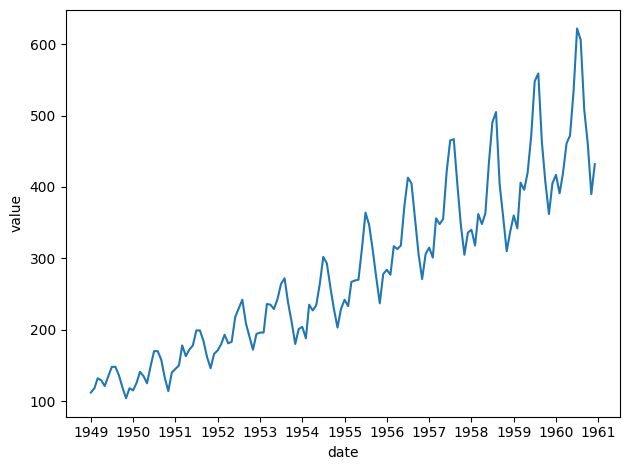

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# Asegurar que date sea datetime
data["date"] = pd.to_datetime(data["date"])

ax = sns.lineplot(x=data["date"], y=data["value"])

# Mostrar solo años
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

De un primer vistazo podemos sacar las siguientes conclusiones:

- Tiene tendencia creciente
- Tiene estacionalidad anual (cada 12 meses)
- Tiene una varianza creciente (la amplitud de las oscilaciones es cada vez mayor)


### Transformaciones para estabilizar la varianza

Primero para lograr una estacionriedad aplicaremos una transformación logarítmica a la serie de tiempo, esto nos ayudará a estabilizar la varianza creciente que observamos en los datos. Luego, aplicaremos una diferenciación estacional para eliminar la estacionalidad anual.

In [10]:
import numpy as np

# transformacion logaritmica
data["log_value"] = np.log(data["value"])
data.head()

,date,value,log_value
0,1949-01-01,112,4.718499
1,1949-02-01,118,4.770685
2,1949-03-01,132,4.882802
3,1949-04-01,129,4.859812
4,1949-05-01,121,4.795791


In [43]:
# año inferior y año superior son:
start_year = data["date"].dt.year.min()
end_year = data["date"].dt.year.max()
print("Año inferior:", start_year)
print("Año superior:", end_year)

Año inferior: 1949
Año superior: 1960


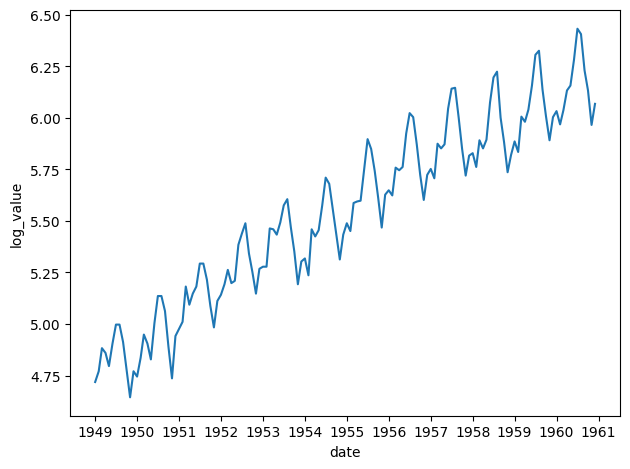

In [11]:
# grafica de la serie transformada
ax = sns.lineplot(x=data["date"], y=data["log_value"])
# Mostrar solo años
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

Ahora aplicaremos la diferenciación estacional para eliminar la estacionalidad anual. Esto se hace restando el valor de cada observación con el valor de la misma observación pero del año anterior (12 meses antes).

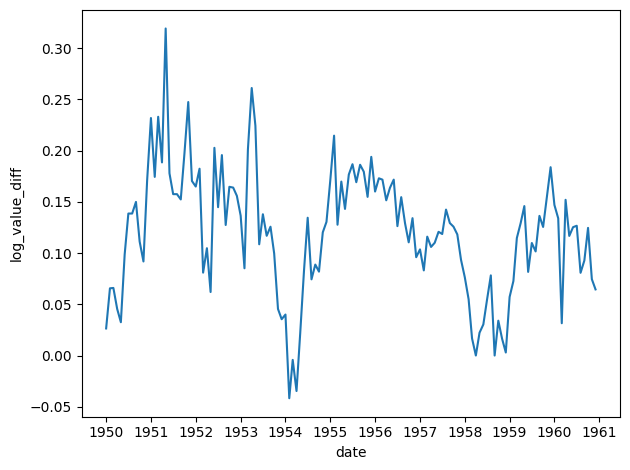

In [13]:
# diferenciacion estacional
data["log_value_diff"] = data["log_value"] - data["log_value"].shift(12)

# grafica de la serie diferenciada
ax = sns.lineplot(x=data["date"], y=data["log_value_diff"])
# Mostrar solo años
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

Ahora podemos aplicar una diferenciación no estacional adicional, para eliminar cualquier tendencia residual que pueda quedar en la serie después de la diferenciación estacional. Esto se hace restando el valor de cada observación con el valor de la observación anterior (1 mes antes).

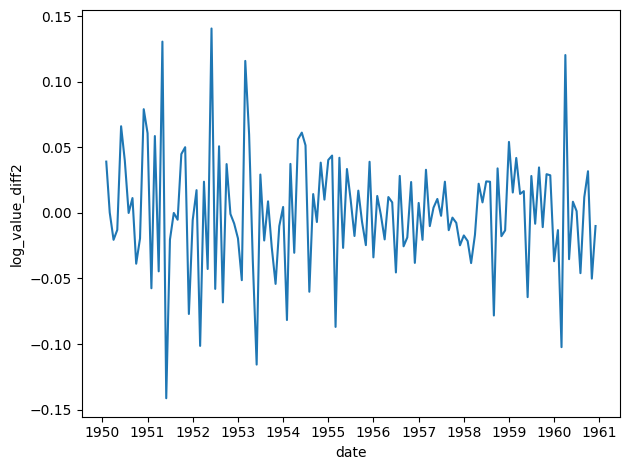

In [14]:
# aplicar diferenciación no estacional adicional
data["log_value_diff2"] = data["log_value_diff"] - data["log_value_diff"].shift(1)
# grafica de la serie diferenciada dos veces
ax = sns.lineplot(x=data["date"], y=data["log_value_diff2"])
# Mostrar solo años
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

### Verificacion Estacionariedad

Ahora aplicaremos la prueba de Dickey-Fuller aumentada para verificar si la serie transformada es estacionaria. Esta prueba nos ayudará a determinar si podemos proceder con el modelado SARIMA o si necesitamos aplicar más transformaciones para lograr la estacionariedad.

In [17]:
# aplicamos la prueba de Dickey-Fuller aumentada sobre el modelo doblemente diferenciado
from statsmodels.tsa.stattools import adfuller
result = adfuller(data["log_value_diff2"].dropna())
print("ADF Statistic: %f" % result[0])
if result[1] < 0.05:
    print("La serie es estacionaria (rechazamos H0)")
else:
    print("La serie no es estacionaria (no rechazamos H0)")

print("p-value: %f" % result[1])

ADF Statistic: -4.443325
La serie es estacionaria (rechazamos H0)
p-value: 0.000249


En consecuencia podemos afirmar entonces que las transformaciones aplicadas han sido suficientes para lograr la estacionariedad de la serie, lo que nos permitirá proceder con el modelado SARIMA para realizar predicciones futuras.

## Identificacion del Módelo SARIMA

Ahora vamos a identificar los parámetros del modelo SARIMA utilizando las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) para determinar los valores de p, d, q, P, D, Q y m.

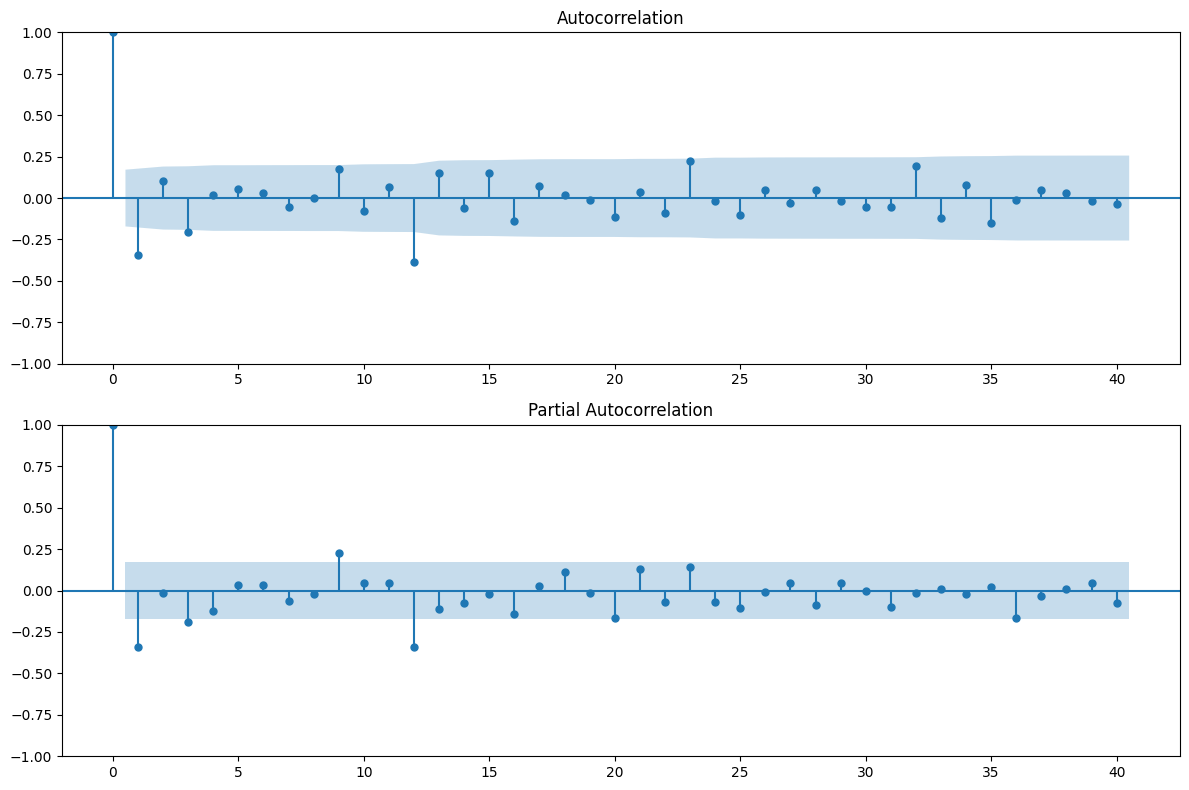

In [22]:
# graficamos ACF y PACF para la serie transformada
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(2, 1, figsize=(12,8))
plot_acf(data["log_value_diff2"].dropna(), ax=ax[0], lags=(40))
plot_pacf(data["log_value_diff2"].dropna(), ax=ax[1], lags=(40))  
plt.tight_layout()
plt.show()

Al ver los gráficos ACF y PACF de la serie ya estacionaria, se nota que la relación entre los datos va desapareciendo rápido, lo que indica que la serie quedó bastante estable después de las transformaciones. 

En la ACF aparecen picos claros en los rezagos estacionales (cada 12 meses), lo que muestra que hay un patrón que se repite cada año. En cambio, la PACF solo tiene algunos picos pequeños al inicio y en los rezagos estacionales, pero sin un patrón muy marcado.

Con base en esto y teniendo en cuenta que los datos tienen estacionalidad anual, se probarán dos modelos SARIMA. El primero es un SARIMA (1,1,1)(1,1,1)[12], que es un modelo básico y común para este tipo de series. El segundo es un SARIMA (2,1,1)(0,1,1)[12], que agrega un poco más de complejidad para comparar cuál se ajusta mejor a los datos.

In [25]:
# modelo 1 SARIMA (1,1,1)(1,1,1)[12]
from statsmodels.tsa.statespace.sarimax import SARIMAX
model1 = SARIMAX(data["log_value"], order=(1,1,1), seasonal_order=(1,1,1,12))
results1 = model1.fit()
print(results1.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          log_value   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 245.152
Date:                            Sat, 11 Apr 2026   AIC                           -480.304
Time:                                    18:40:18   BIC                           -465.928
Sample:                                         0   HQIC                          -474.462
                                            - 144                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1694      0.212      0.797      0.425      -0.247       0.586
ma.L1         -0.5640      0.184   

In [26]:
# modelo 2 SARIMA (2,1,1)(0,1,1)[12]
model2 = SARIMAX(data["log_value"], order=(2,1,1), seasonal_order=(0,1,1,12))
results2 = model2.fit()
print(results2.summary())   


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                      
Dep. Variable:                          log_value   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 246.125
Date:                            Sat, 11 Apr 2026   AIC                           -482.250
Time:                                    18:40:38   BIC                           -467.874
Sample:                                         0   HQIC                          -476.409
                                            - 144                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5512      0.099      5.541      0.000       0.356       0.746
ar.L2          0.2433      0.087   

In [27]:
# tabla para comparar los modelos
comparison = pd.DataFrame({
    "Modelo": ["SARIMA(1,1,1)(1,1,1)[12]", "SARIMA(2,1,1)(0,1,1)[12]"],
    "AIC": [results1.aic, results2.aic],
    "BIC": [results1.bic, results2.bic]
})
print(comparison)

                     Modelo         AIC         BIC
0  SARIMA(1,1,1)(1,1,1)[12] -480.303699 -465.927712
1  SARIMA(2,1,1)(0,1,1)[12] -482.250401 -467.874414


podemos decir que el Modelo SARIMA (1,1,1)(1,1,1)[12] es el que tiene el mejor ajuste a los datos, ya que tiene un AIC y BIC más bajos en comparación con el modelo SARIMA (2,1,1)(0,1,1)[12]. Esto indica que el modelo más simple es suficiente para capturar la dinámica de la serie de tiempo sin necesidad de agregar complejidad adicional.

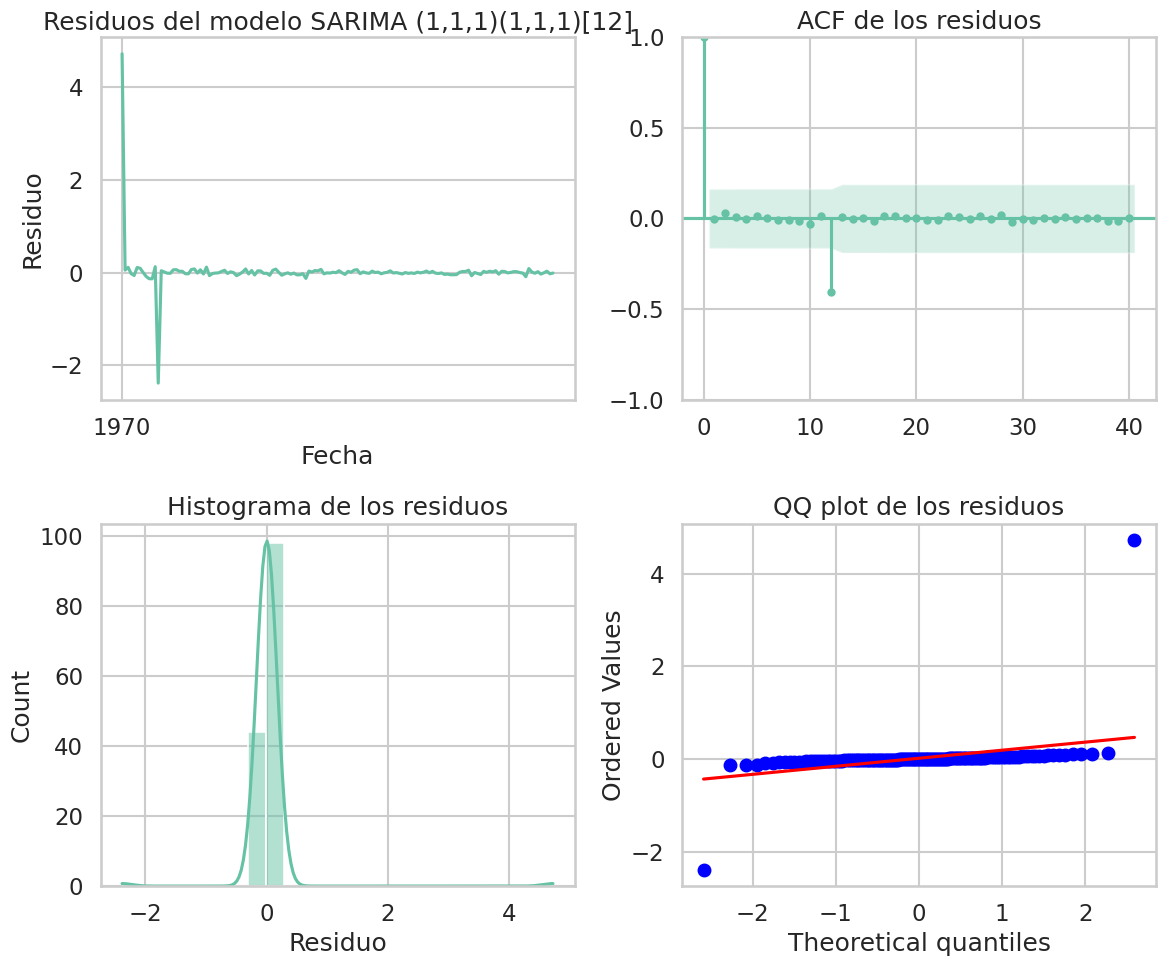

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats

# Residuos del modelo
residuals1 = results1.resid.dropna()

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Residuos en el tiempo
sns.lineplot(
    x=residuals1.index,
    y=residuals1,
    ax=ax[0, 0]
)
ax[0, 0].xaxis.set_major_locator(mdates.YearLocator())
ax[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax[0, 0].set_title("Residuos del modelo SARIMA (1,1,1)(1,1,1)[12]")
ax[0, 0].set_xlabel("Fecha")
ax[0, 0].set_ylabel("Residuo")

# ACF de los residuos
plot_acf(
    residuals1,
    lags=40,
    ax=ax[0, 1]
)
ax[0, 1].set_title("ACF de los residuos")

# histograma de los residuos
sns.histplot(
    residuals1,
    kde=True,
    ax=ax[1, 0]
)
ax[1, 0].set_title("Histograma de los residuos")
ax[1, 0].set_xlabel("Residuo")

#QQ plot de los residuos
stats.probplot(residuals1, dist="norm", plot=ax[1, 1])
ax[1, 1].set_title("QQ plot de los residuos")

plt.tight_layout()
plt.show()

Hacemo una prueba de Ljung-Box para verificar la independencia de los residuos del modelo SARIMA (1,1,1)(1,1,1)[12]. Esta prueba nos ayudará a determinar si los residuos del modelo son independientes entre sí, lo que es un supuesto importante para la validez del modelo.

In [39]:
# ljung-box test para verificar la corrrelacion de los residuos
from statsmodels.stats.diagnostic import acorr_ljungbox
ljung_box_results = acorr_ljungbox(residuals1, lags=[10], return_df=True)
if ljung_box_results["lb_pvalue"].values[0] < 0.05:
    print("Los residuos no se correlacionan (rechazamos H0)")
else:    print("Los residuos se correlacionan (no rechazamos H0)")

print("Ljung-Box p-value: %f" % ljung_box_results["lb_pvalue"].values[0])

Los residuos se correlacionan (no rechazamos H0)
Ljung-Box p-value: 0.999998


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


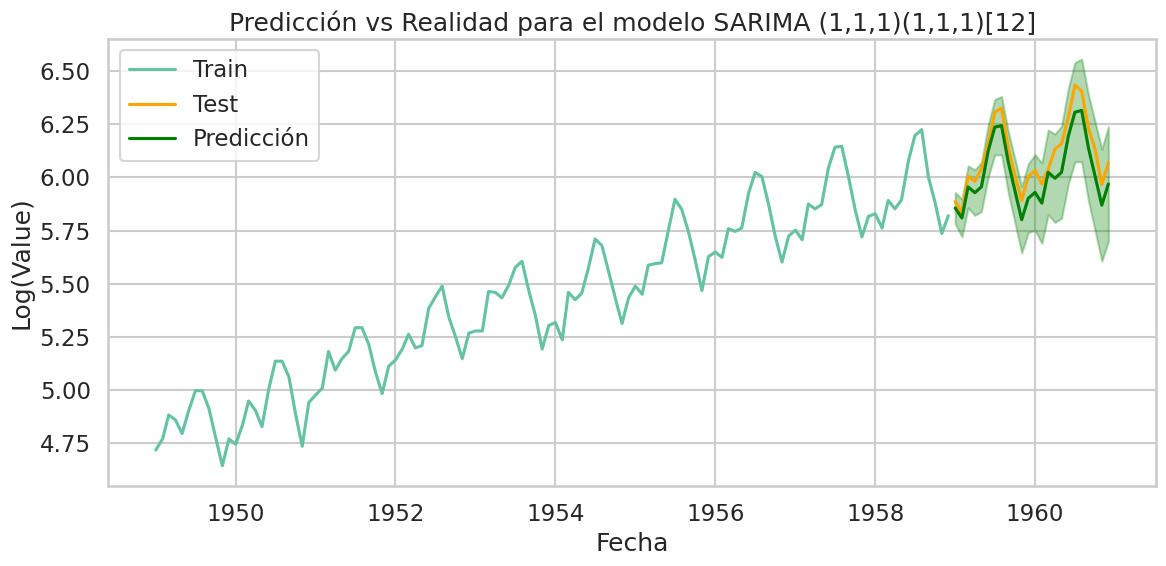

In [51]:
# ahora vamos a dividir la serie en train y test para evaluar el poder predictivo del modelo
train = data.iloc[:-24]  # Usamos los primeros 108 meses para entrenar
test = data.iloc[-24:]   # Usamos los últimos 24 meses para probar

# usaremos el modelo 1 para hacer predicciones
model_final = SARIMAX(train["log_value"], order=(1,1,1), seasonal_order=(1,1,1,12))
results_final = model_final.fit()
predictions = results_final.get_forecast(steps=24)
predicted_mean = predictions.predicted_mean
predicted_ci = predictions.conf_int()

# comparar pronosticos con valores reales de prueba y graficar
plt.figure(figsize=(12, 6))
plt.plot(train["date"], train["log_value"], label="Train")
plt.plot(test["date"], test["log_value"], label="Test", color="orange")
plt.plot(test["date"], predicted_mean, label="Predicción", color="green")
plt.fill_between(test["date"], predicted_ci.iloc[:, 0], predicted_ci.iloc[:, 1], color="green", alpha=0.3)
plt.legend()
plt.title("Predicción vs Realidad para el modelo SARIMA (1,1,1)(1,1,1)[12]")
plt.xlabel("Fecha")
plt.ylabel("Log(Value)")
plt.tight_layout()
plt.show() 

In [41]:
# calcumos metricas de evaluacion ECM y MAPE
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
mse = mean_squared_error(test["log_value"], predicted_mean)
mape = mean_absolute_percentage_error(test["log_value"], predicted_mean)
print("MSE: %f" % mse)
print("MAPE: %f" % mape)

MSE: 0.007768
MAPE: 0.013325


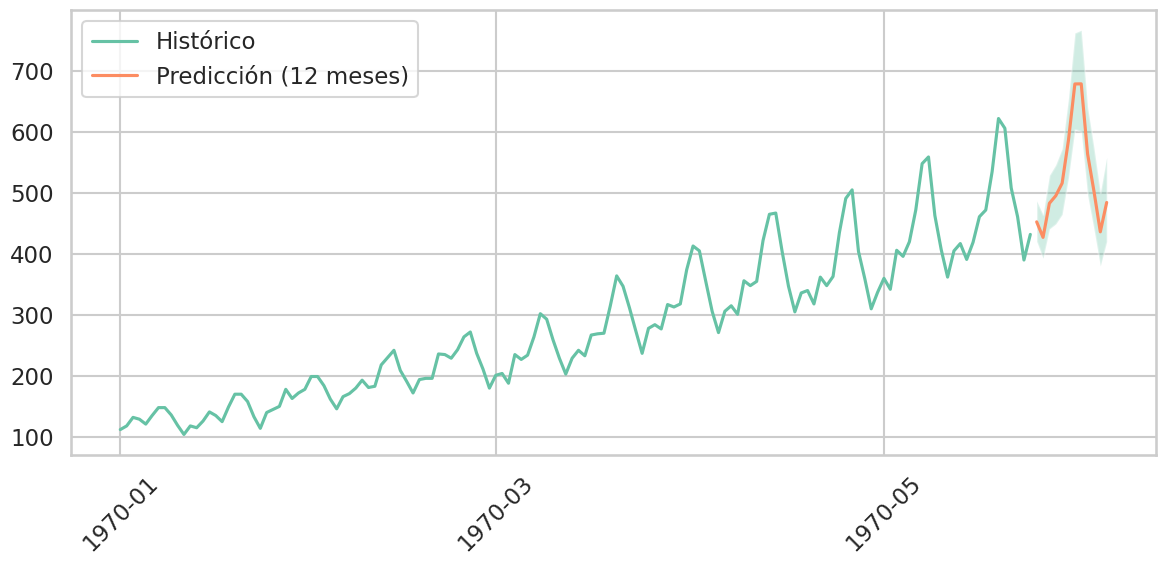

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ajustar SARIMA
model = SARIMAX(
    data["log_value"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit()

# Forecast 12 meses
forecast = results.get_forecast(steps=12)
mean_log = forecast.predicted_mean
ci_log = forecast.conf_int()

mean = np.exp(mean_log)
ci_lower = np.exp(ci_log.iloc[:, 0])
ci_upper = np.exp(ci_log.iloc[:, 1])

# Gráfica
plt.figure(figsize=(12, 6))
plt.plot(data.index, data["value"], label="Histórico")
plt.plot(mean.index, mean, label="Predicción (12 meses)")
plt.fill_between(mean.index, ci_lower, ci_upper, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

In [60]:
# descargamos el html de este cuaderno usando nbconvert

!jupyter nbconvert --to html taller_2.ipynb


[NbConvertApp] Converting notebook taller_2.ipynb to html
[NbConvertApp] Writing 1272707 bytes to taller_2.html
